In [1]:
import torch
torch.__version__

'2.6.0+cu124'

In [2]:
# from drcnet_hybrid_multiple_networks.run import main
# from drcnet_hybrid.run import main
from restormer_hybrid.run import main
# from mds2s.run import main

In [ ]:
# Noise sweep: train and validate over different noise levels and distributions (same-condition).
# Uses DRCNet-hybrid; each run gets its own checkpoint/metrics dir and wandb run name/tags.
from drcnet_hybrid.run import main

NOISE_SWEEP = [
    (0.05, "rician"),
    (0.1, "rician"),
    (0.15, "rician"),
    (0.05, "gaussian"),
    (0.1, "gaussian"),
    (0.15, "gaussian"),
    (0.05, "noncentral_chi"),
    (0.1, "noncentral_chi"),
    (0.15, "noncentral_chi"),
]

for sigma, nt in NOISE_SWEEP:
    print(f"--- Noise sweep: sigma={sigma}, type={nt} ---")
    try:
        main(
            "dbrain",
            train=True,
            reconstruct=True,
            generate_images=False,
            noise_sigma=sigma,
            noise_type=nt,
        )
    except Exception as e:
        print(f"Condition sigma={sigma} type={nt} failed: {e}")
        continue
print("Noise sweep finished.")

2026-03-08 13:04:17,444 - root - INFO - Logging configured - level: INFO, file: logs/training_20260308_130417.log
2026-03-08 13:04:17,447 - root - INFO - Starting Restormer3D training with dataset: dbrain
2026-03-08 13:04:17,448 - root - INFO - Loading config from: /home/paco/TechJourney/TechJourney/DWMRI/src/restormer_hybrid/config.yaml
2026-03-08 13:04:17,449 - root - INFO - Loading configuration from: /home/paco/TechJourney/TechJourney/DWMRI/src/restormer_hybrid/config.yaml
2026-03-08 13:04:17,481 - root - INFO - Configuration file loaded successfully
2026-03-08 13:04:17,483 - root - INFO - Configuration converted to Munch object
2026-03-08 13:04:17,485 - root - INFO - Configuration loaded successfully
2026-03-08 13:04:17,486 - root - INFO - Using DBrain dataset configuration
2026-03-08 13:04:17,487 - root - INFO - DBrainDataLoader initialized - nii_path: /home/paco/d_brain/D_BRAIN_b2500_6_60_14_HCP_nless.nii, bvecs_path: /home/paco/d_brain/D_BRAIN_b2500_6_60_HCP_b_matrix.txt, bvalu

2026-03-08 13:04:20,088 - root - INFO - Loading data...
2026-03-08 13:04:20,090 - root - INFO - Loading data from /home/paco/d_brain/D_BRAIN_b2500_6_60_14_HCP_nless.nii
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-03-08 13:04:20,092 - nibabel.global - INFO - pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-03-08 13:04:20,096 - root - INFO - Raw data loaded - shape: (128, 128, 97, 66), dtype: float64
2026-03-08 13:04:20,567 - root - INFO - Raw data stats - min: 0.0000, max: 7462.0000, mean: 159.3769
2026-03-08 13:04:20,568 - root - INFO - Normalizing spatial dimensions...
2026-03-08 13:04:20,570 - root - INFO - Normalizing spatial dimensions for data of shape (128, 128, 97, 66)
2026-03-08 13:04:22,185 - root - INFO - Spatial normalization completed - output shape: (128, 128, 97, 66)
2026-03-08 13:04:22,343 - root - INFO - Normalized data stats - min: 0.0000, max: 1.0000, mean: 0.1140
2026-03-08 13:04:22,344 - root - INFO - Adding Rician noise 

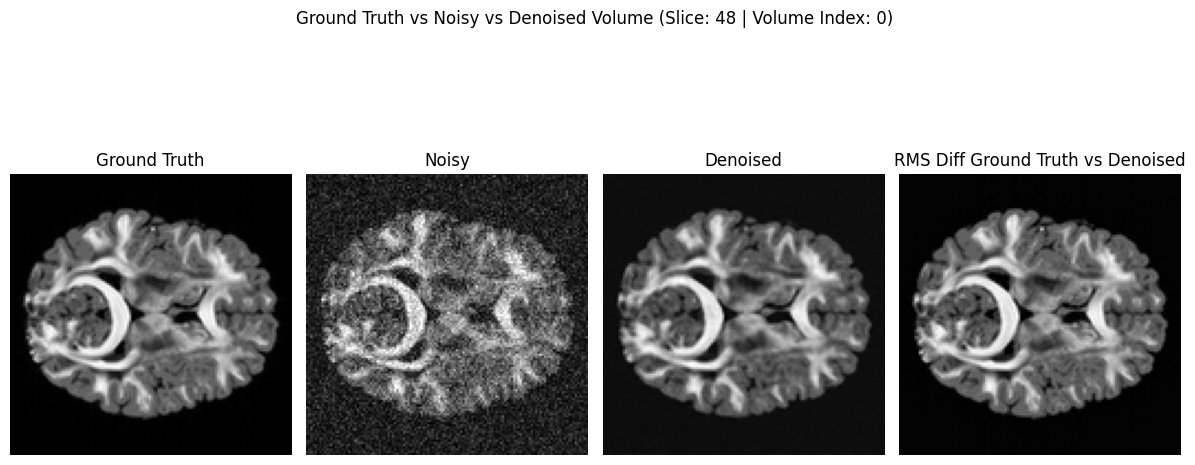

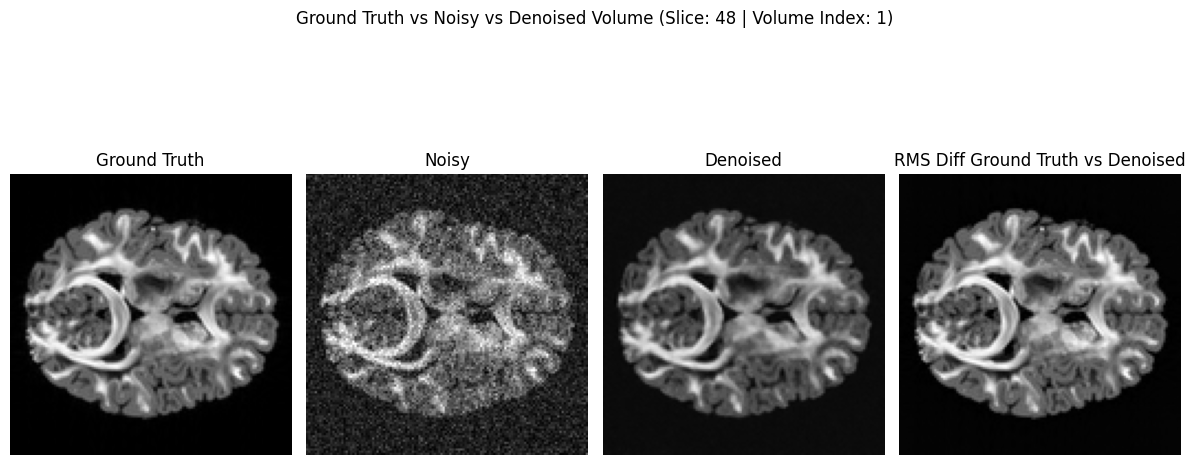

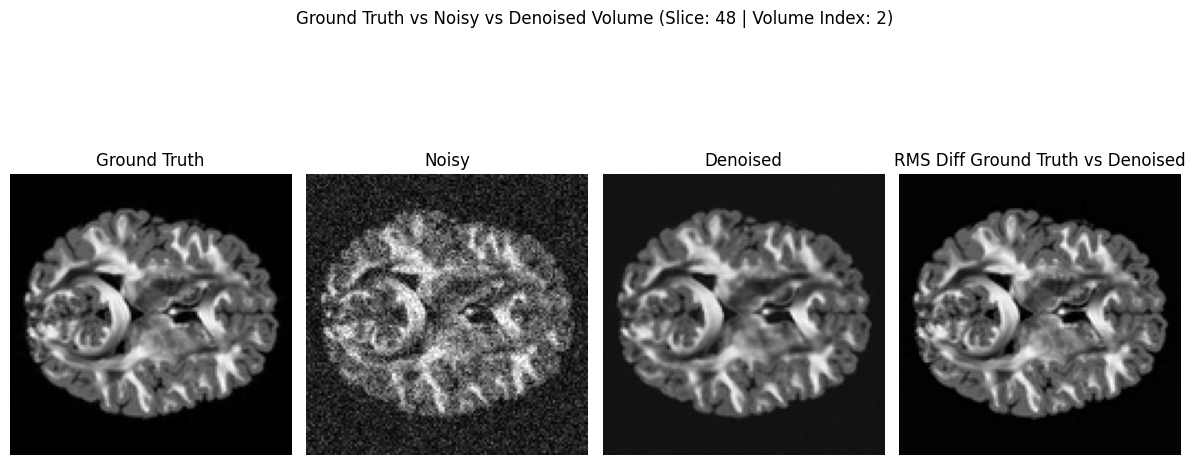

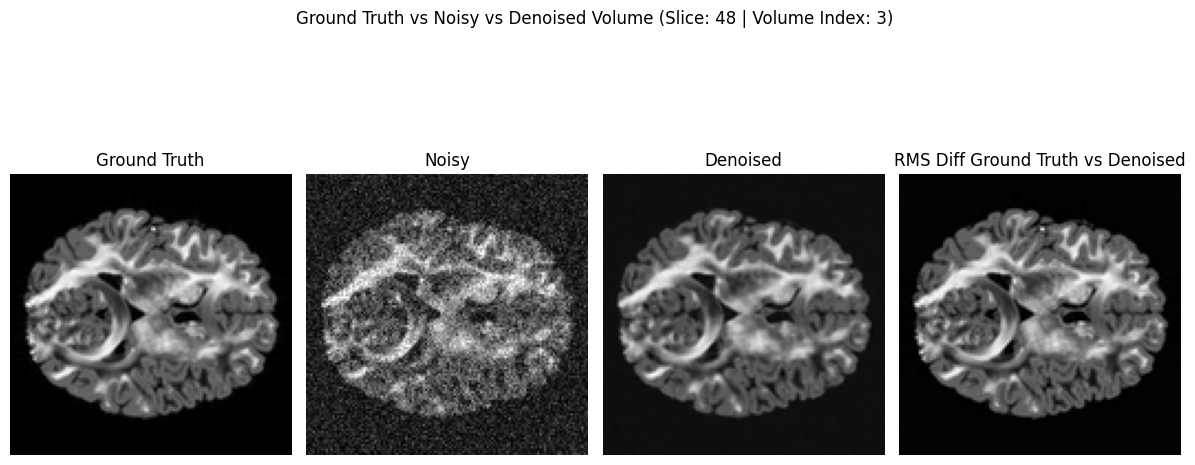

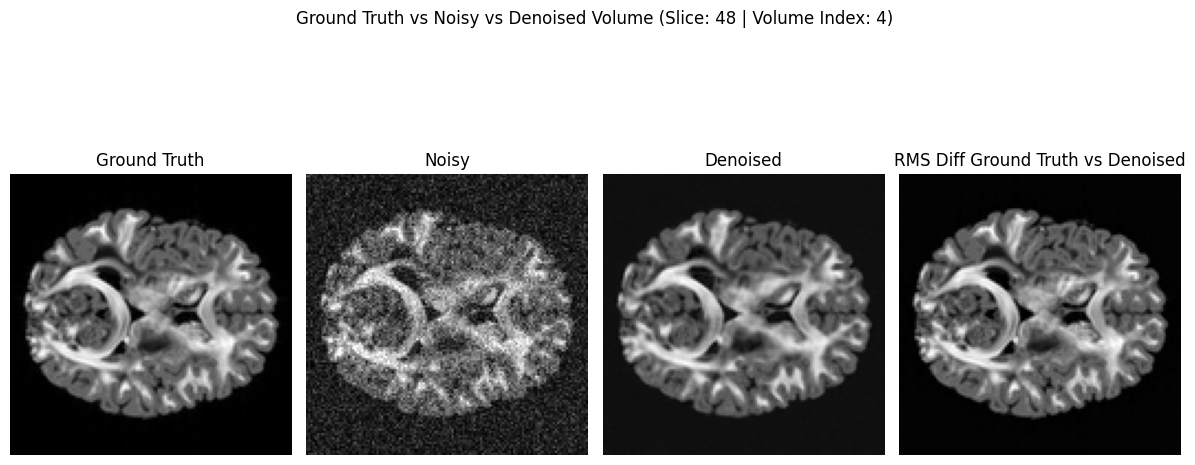

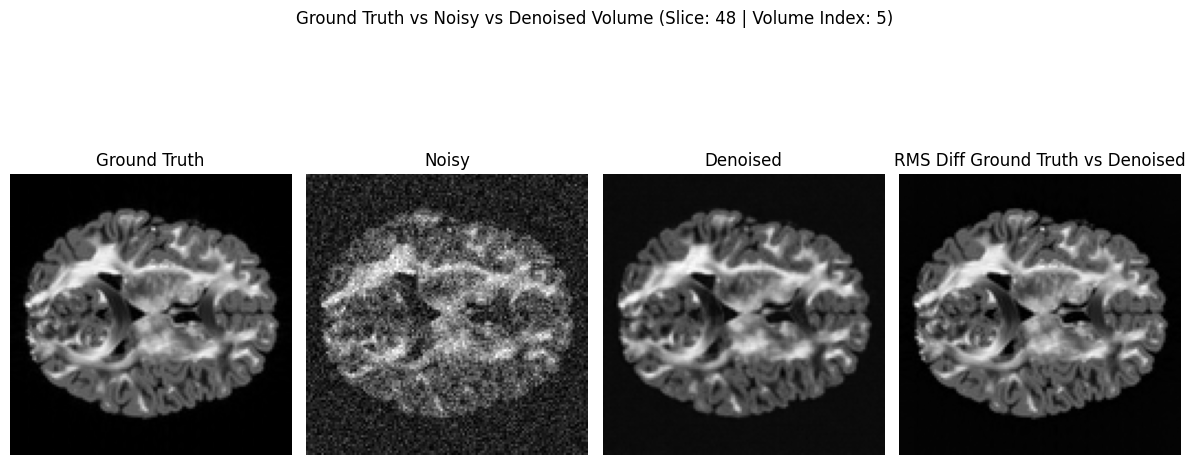

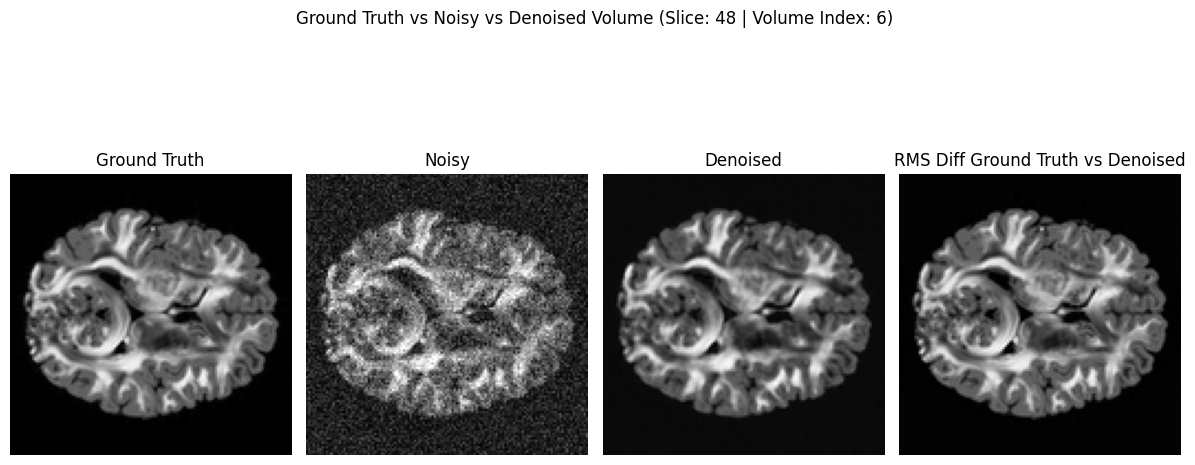

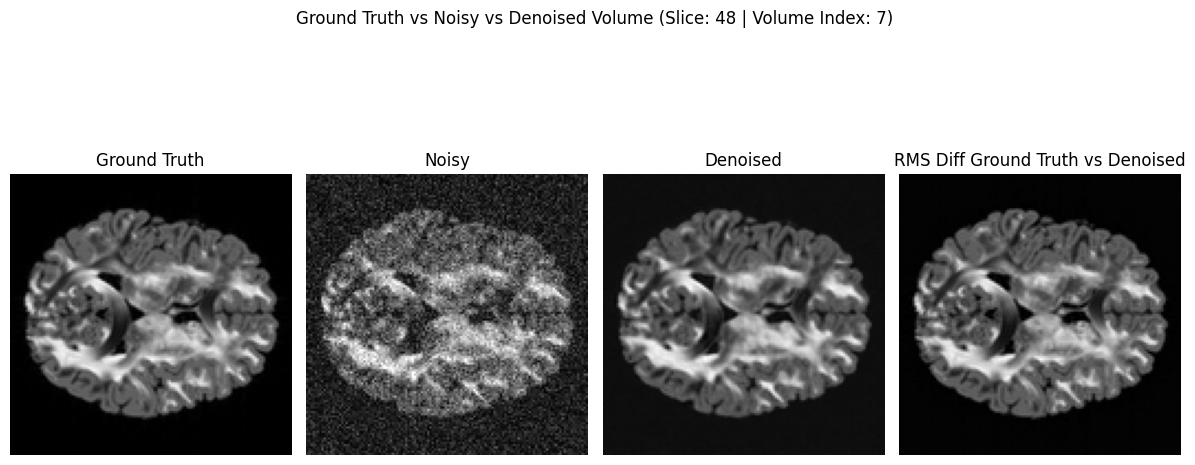

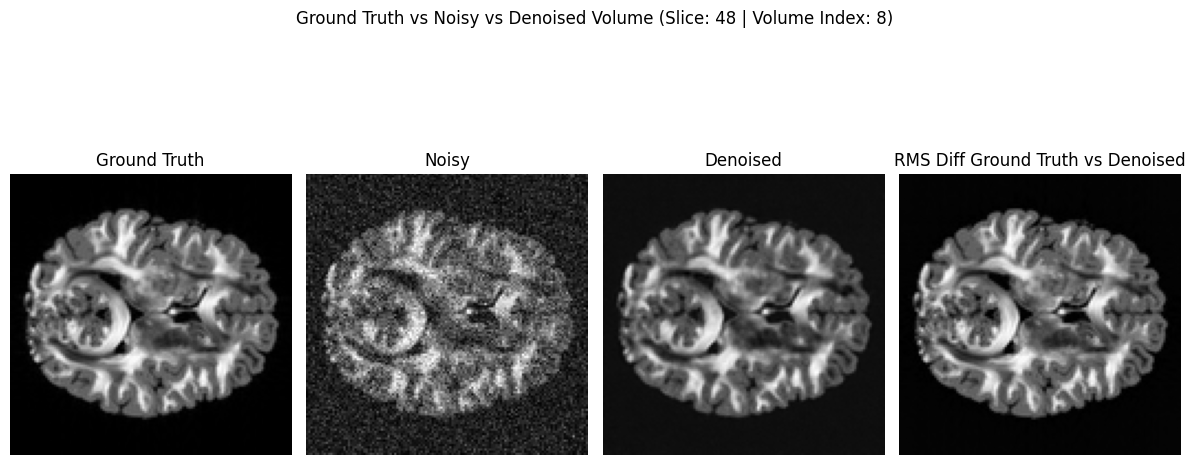

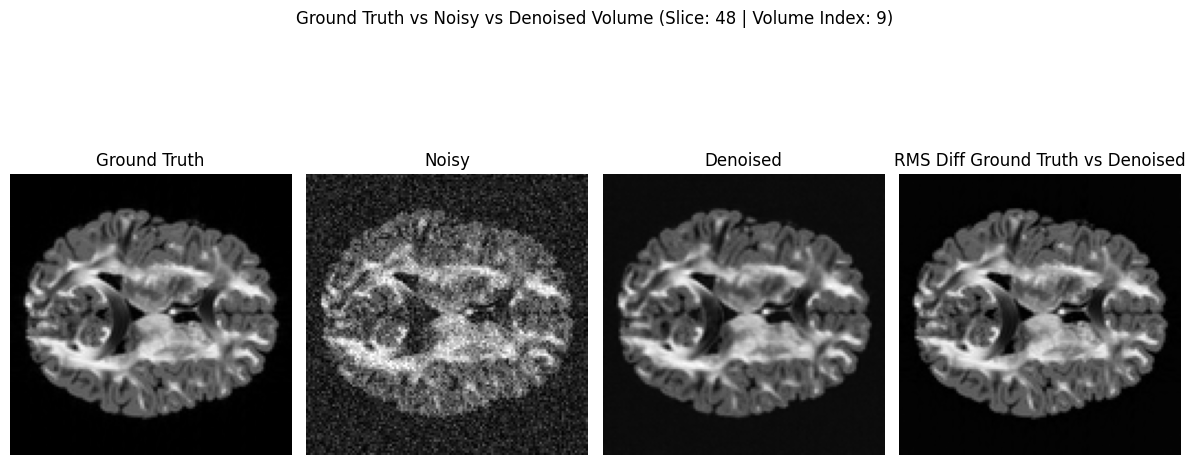

(96, 10, 128, 128)


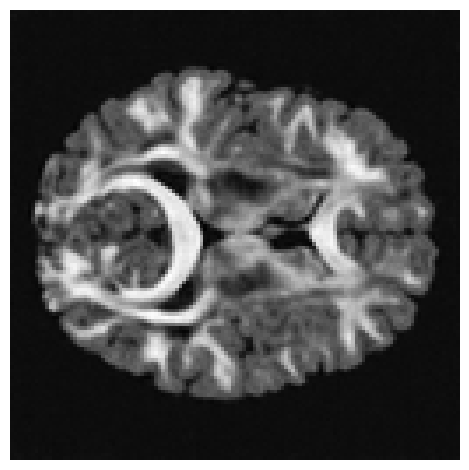

(96, 10, 128, 128)


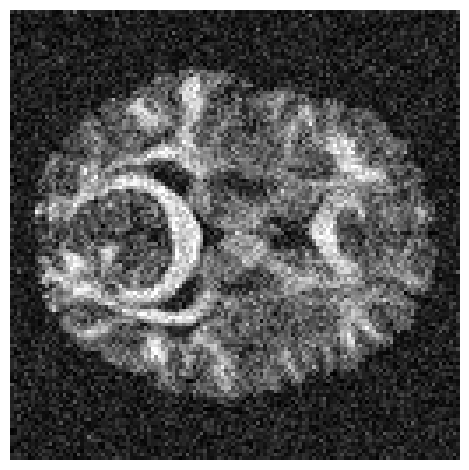

epoch,▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇█▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇██
progressive/batch_size,█▄▁
progressive/patch_size,▁▅█
progressive/stage,▁▅█
reconstruct/metrics_mse,▁
reconstruct/metrics_psnr,▁
reconstruct/metrics_roi_mse,▁
reconstruct/metrics_roi_psnr,▁
reconstruct/metrics_roi_ssim,▁
reconstruct/metrics_ssim,▁
train/best_loss,▅▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁█▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁


In [3]:
main("dbrain")

# metrics

## mds2s
### 0.1 {'psnr': 20.75483775311783, 'ssim': 0.3659183382987976, 'mse': 0.008404584049680605}

## drcnet
### 0.1 {'psnr': 21.002585178163354, 'ssim': 0.3720719814300537, 'mse': 0.00793855544179678}

## drcnet sinusoidal encoding with CBAM and mean input -- lr 0.001
### {'psnr': 19.70985296358925, 'ssim': 0.3897143304347992, 'mse': 0.010690910741686821}

# Reconstructed DWIs min: 0.0461, max: 1.0992, mean: 0.2084
# Original DWIs min: 0.0000, max: 1.0000, mean: 0.1140